In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pylab as plt

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM, GRU
from keras.layers import Dropout

import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
data_file = '../input/twse-fs/indexes/IXIC.csv'
df = pd.read_csv(data_file)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1971-02-05,100.000000,100.000000,100.000000,100.000000,100.000000,0
1,1971-02-08,100.839996,100.839996,100.839996,100.839996,100.839996,0
2,1971-02-09,100.760002,100.760002,100.760002,100.760002,100.760002,0
3,1971-02-10,100.690002,100.690002,100.690002,100.690002,100.690002,0
4,1971-02-11,101.449997,101.449997,101.449997,101.449997,101.449997,0


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  """Entry point for launching an IPython kernel.


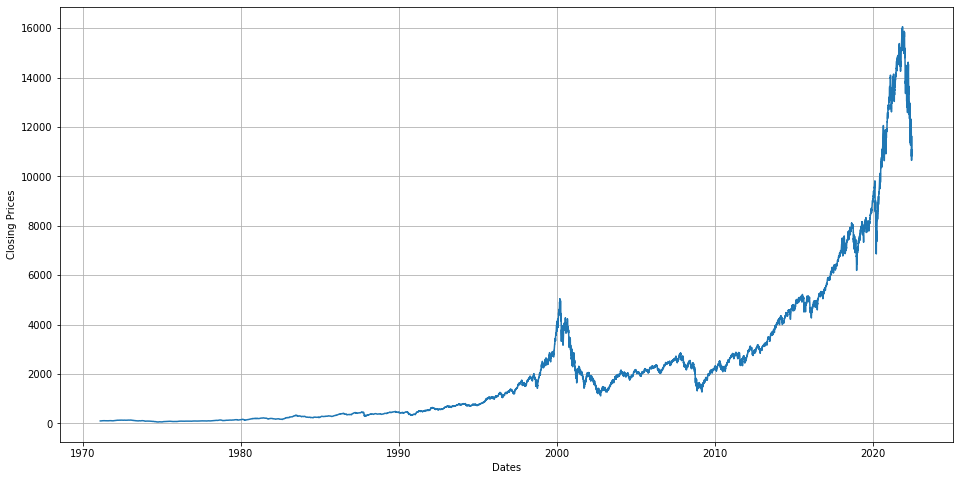

In [3]:
dateparse = lambda dates: pd.datetime.strptime(dates, '%Y-%m-%d')
data = pd.read_csv(data_file, sep=',', parse_dates=['Date'], index_col='Date',date_parser=dateparse)
#data = data.loc['2012-11-10':'2017-11-10']
plt.figure(figsize=(16,8))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(data['Close'])

In [4]:
# Split train and test data
train_start_idx = -7000
train_end_idx = -500

print('Training data range: ', df.iloc[train_start_idx]['Date'], ' - ', df.iloc[train_end_idx]['Date'])
print('Test data range: ', df.iloc[train_end_idx]['Date'], ' - ', df.iloc[-1]['Date'])

Training data range:  1994-09-07  -  2020-07-01
Test data range:  2020-07-01  -  2022-06-24


In [5]:
train_data = df[train_start_idx:train_end_idx].drop(columns=['Date']).to_numpy()
test_data = df[train_end_idx:].drop(columns=['Date']).to_numpy()
print(df.iloc[train_start_idx])
print("\n **** Convert stock data into numpy tensor ****")
print('Number of Training data: ', len(train_data))

Date         1994-09-07
Open          760.51001
High         765.119995
Low          760.070007
Close        764.280029
Adj Close    764.280029
Volume        283770000
Name: 5960, dtype: object

 **** Convert stock data into numpy tensor ****
Number of Training data:  6500


In [6]:
train_data[-1]

array([9.87529004e+03, 1.00855898e+04, 9.86366992e+03, 1.00587695e+04,
       1.00587695e+04, 4.47400000e+09])

In [7]:
def parseSlice(sliceStr):
    return tuple((slice(*(int(i) if i else None for i in part.strip().split(':'))) if ':' in part else int(part.strip())) for part in sliceStr.split(','))

In [8]:
# Adapted from Keras Time Series Data ts_generator_bn. Note that we add two options:
# batch_norm: Use the beginning price of a sample price series to normalize data
# target_index: The index of target value (label) in our tensor. Our target is Adjusted closed price (index: -2) 

def ts_generator_bn(data, lookback, delay, min_index=0, max_index=None, shuffle=False, 
              batch_size=128, step=1, target_index=0, batch_norm=True, norm_feat_index=":"):
    if max_index is None:
        max_index = len(data) - delay   # == real array index + 1
    i = min_index + lookback            # == real array index + 1
    while 1:
        if shuffle:
            rows = np.random.randint(min_index + lookback, max_index, size=batch_size)
        else:
            if i + batch_size > max_index:
                i = min_index + lookback
            rows = np.arange(i, min(i + batch_size, max_index))
            i += len(rows)
        samples = np.zeros((len(rows), lookback // step, data.shape[-1]))
        targets = np.zeros((len(rows),))
        for j, row in enumerate(rows):
            indices = range(rows[j] - lookback, rows[j], step)
            if batch_norm:
                ## Normalize data using first datium in the series
                norm = data[indices[0]]
                #samples[j] = data[indices] / norm
                # Convert string filter to index
                feat_ind = parseSlice(norm_feat_index)
                sample_ind = parseSlice(str(j) + ',:,' + norm_feat_index)
                samples[j] = data[indices]
                # Original command: samples[j,:,feat_ind] = samples[j,:,feat_ind]  / norm[feat_ind]
                samples[sample_ind] = samples[sample_ind]  / norm[feat_ind] 
                targets[j] = data[indices[-1] + delay][target_index] / norm[target_index]
            else:
                samples[j] = data[indices]
                targets[j] = data[indices[-1] + delay][target_index]
        yield samples, targets


In [9]:
# Get prediciton target index (Close) of our tensor, remember to -1 because we remove the 'Date' column
target_idx = df.columns.get_loc('Close') - 1
target_idx

3

In [10]:
lookback = 60 # Using last N trading days as input data
step = 1
delay = 1 # Prdict the price in next N days
batch_size = 10 
num_val_data = 100 # Use 100 days as validate data 

train_gen = ts_generator_bn(train_data[0: ],
                      lookback=lookback,
                      delay=delay,
                      max_index= len(train_data) - num_val_data - 1,
                      step=step, 
                      batch_norm=True,
                      target_index = target_idx,
                      batch_size=batch_size)

val_gen = ts_generator_bn(train_data,
                      lookback=lookback,
                      delay=delay,
                      step=step, 
                      min_index= len(train_data) - num_val_data,
                      batch_norm=True,
                      target_index = target_idx,
                      batch_size=batch_size)

val_steps = (num_val_data - lookback) // batch_size


In [11]:
from keras.models import Sequential
from keras import layers

model = Sequential()
model.add(layers.LSTM(16, return_sequences=True, input_shape=(None, train_data.shape[-1])))
model.add(layers.LSTM(8))
model.add(layers.Dense(1))
model.compile(optimizer='RMSprop', loss='mae')

2022-06-28 15:48:47.991587: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-06-28 15:48:48.120421: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-06-28 15:48:48.121300: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-06-28 15:48:48.123303: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, None, 16)          1472      
_________________________________________________________________
lstm_1 (LSTM)                (None, 8)                 800       
_________________________________________________________________
dense (Dense)                (None, 1)                 9         
Total params: 2,281
Trainable params: 2,281
Non-trainable params: 0
_________________________________________________________________


In [13]:
history = model.fit_generator(train_gen, 
                            steps_per_epoch=500, epochs=50,
                            validation_data=val_gen,
                            validation_steps=val_steps)

Epoch 1/50


/opt/conda/lib/python3.7/site-packages/keras/engine/training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '
2022-06-28 15:48:52.037696: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2022-06-28 15:48:55.719312: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


500/500 [==============================] - 11s 12ms/step - loss: 0.0618 - val_loss: 0.0951
Epoch 2/50
500/500 [==============================] - 4s 9ms/step - loss: 0.0398 - val_loss: 0.0872
Epoch 3/50
500/500 [==============================] - 5s 9ms/step - loss: 0.0335 - val_loss: 0.0613
Epoch 4/50
500/500 [==============================] - 4s 9ms/step - loss: 0.0254 - val_loss: 0.0637
Epoch 5/50
500/500 [==============================] - 4s 9ms/step - loss: 0.0283 - val_loss: 0.0986
Epoch 6/50
500/500 [==============================] - 5s 10ms/step - loss: 0.0279 - val_loss: 0.0429
Epoch 7/50
500/500 [==============================] - 5s 9ms/step - loss: 0.0249 - val_loss: 0.0702
Epoch 8/50
500/500 [==============================] - 5s 10ms/step - loss: 0.0240 - val_loss: 0.0460
Epoch 9/50
500/500 [==============================] - 4s 9ms/step - loss: 0.0197 - val_loss: 0.0464
Epoch 10/50
500/500 [==============================] - 4s 9ms/step - loss: 0.0222 - val_loss: 0.0435
Epoch 

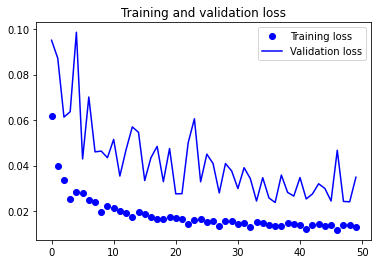

In [14]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [15]:
test_gen = ts_generator_bn(test_data,
                      lookback=lookback,
                      delay=delay,
                      step=step, 
                      batch_norm=True,
                      target_index = target_idx,
                      batch_size=batch_size)

In [16]:
model.evaluate_generator(test_gen, len(test_data))

/opt/conda/lib/python3.7/site-packages/keras/engine/training.py:2006: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  warnings.warn('`Model.evaluate_generator` is deprecated and '


0.01581690087914467

In [17]:
# Prediction price
prices = df.iloc[-lookback:].drop(columns=['Date']).to_numpy()
x = prices / prices[0]
price_sample = np.expand_dims(x, axis=0)
pred = model.predict(price_sample)

pred_price = pred[0][0]*prices[0][target_idx]

print('The NASDAQ price for ', str(delay) ,' trading days after ', df.iloc[-1]['Date'], ' is ' + str(pred_price))


The NASDAQ price for  1  trading days after  2022-06-24  is 12093.229383839505


In [18]:
# Predict recent stock prices

period = 500  # Predict last N Days

prices = df.iloc[-period:].drop(columns=['Date']).to_numpy()

# Generate all stock price series and save in a numpy tensor 
data_mat = np.zeros((period - lookback, lookback, prices.shape[-1]))
for i in range(0, period - lookback):
    data = prices[i: i+lookback] / prices[i]
    data_mat[i] = data

pred = model.predict(data_mat)

pred_prices = []
for i in range(0, period - lookback):
    pred_price = pred[i][0] * prices[i][target_idx]
    pred_prices.append(pred_price)

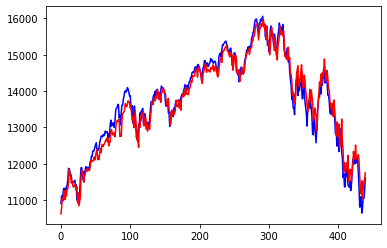

In [19]:
plt.figure()
plt.plot(prices[lookback:,target_idx], color='blue', label='Real Stock Price')
plt.plot(pred_prices, color='red', label='Predicted Stock Price')
plt.show()

In [20]:
abs_err = 0
days = len(prices) - lookback
for i in range(lookback, len(prices)):
    abs_err += abs(prices[i, target_idx] - pred_prices[i - lookback])

abs_err / days

215.6968114665825

In [21]:
# Common sense baseline (Use today's price as tomorrow's prediction)
abs_err = 0
days = len(prices) - lookback
for i in range(lookback-1, len(prices)-1):
    abs_err += abs(prices[i, target_idx] - prices[i+1, target_idx])

abs_err / days

151.49421386818182